In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import numpy as np



df = pd.read_csv('../ressourcen/Train.csv',
                 sep=',',
                 encoding='utf-8',
                 decimal='.'
                 )

print(df.head(10))
print("Rows&Cols: " ,df.shape)
values_data = df.describe()  
data_info = df.info()
unique_values = df.nunique()


print (data_info)
print(unique_values)            

duplikate = df.duplicated().sum()

print(duplikate)


   ID Warehouse_block Mode_of_Shipment  Customer_care_calls  Customer_rating  \
0   1               D           Flight                    4                2   
1   2               F           Flight                    4                5   
2   3               A           Flight                    2                2   
3   4               B           Flight                    3                3   
4   5               C           Flight                    2                2   
5   6               F           Flight                    3                1   
6   7               D           Flight                    3                4   
7   8               F           Flight                    4                1   
8   9               A           Flight                    3                4   
9  10               B           Flight                    3                2   

   Cost_of_the_Product  Prior_purchases Product_importance Gender  \
0                  177                3           

In [4]:
shipping_unique = df['Mode_of_Shipment'].value_counts()
gender_unique = df['Gender'].value_counts()
importance_unique = df['Product_importance'].value_counts()
Warehouse_unique = df['Warehouse_block'].value_counts()
print(shipping_unique)
print(gender_unique)
print(importance_unique)
print(Warehouse_unique)

Mode_of_Shipment
Ship      7462
Flight    1777
Road      1760
Name: count, dtype: int64
Gender
F    5545
M    5454
Name: count, dtype: int64
Product_importance
low       5297
medium    4754
high       948
Name: count, dtype: int64
Warehouse_block
F    3666
D    1834
A    1833
B    1833
C    1833
Name: count, dtype: int64


<Figure size 1000x500 with 0 Axes>

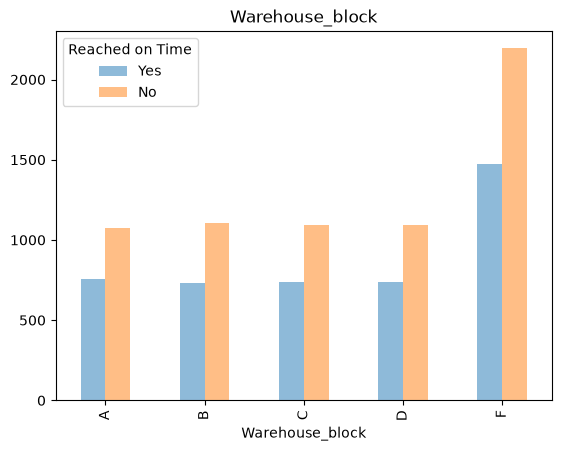

<Figure size 1000x500 with 0 Axes>

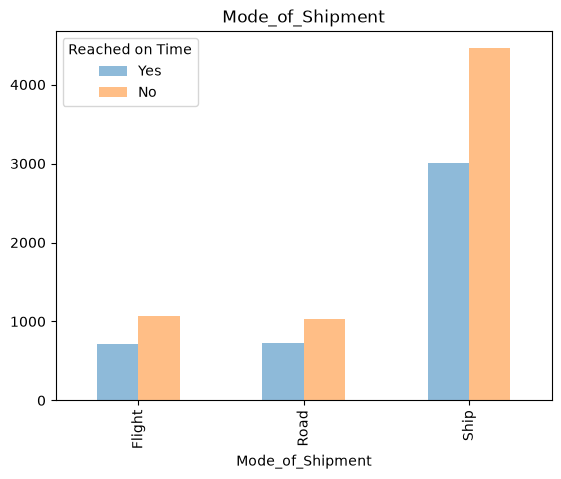

<Figure size 1000x500 with 0 Axes>

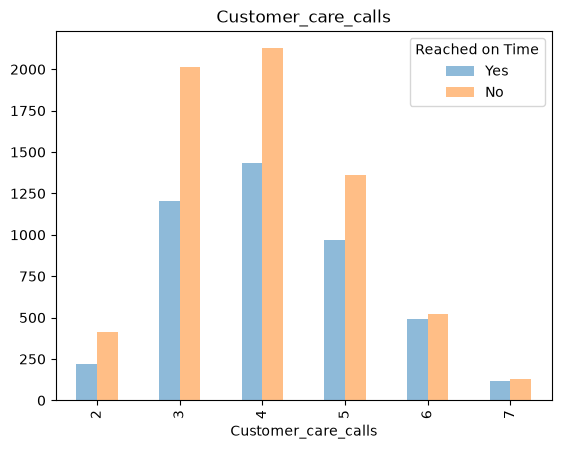

<Figure size 1000x500 with 0 Axes>

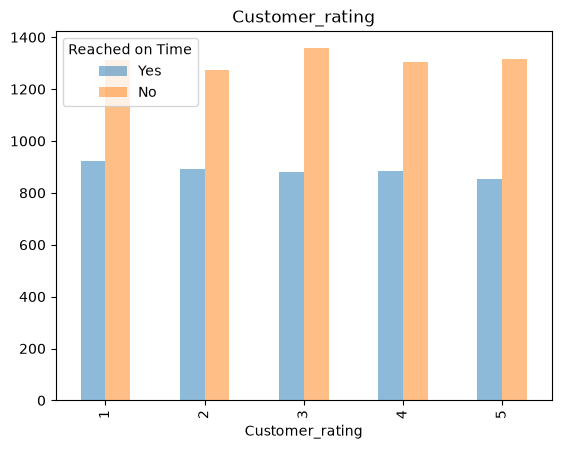

<Figure size 1000x500 with 0 Axes>

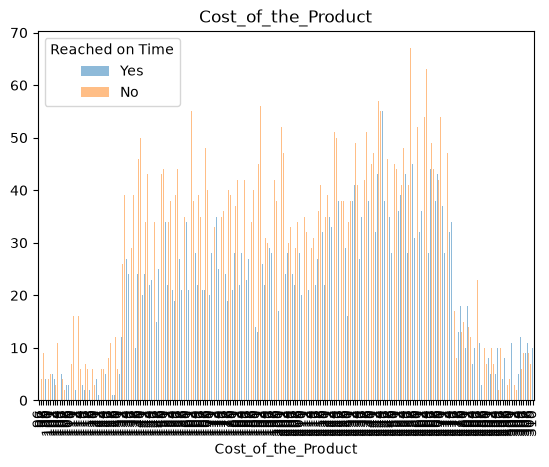

<Figure size 1000x500 with 0 Axes>

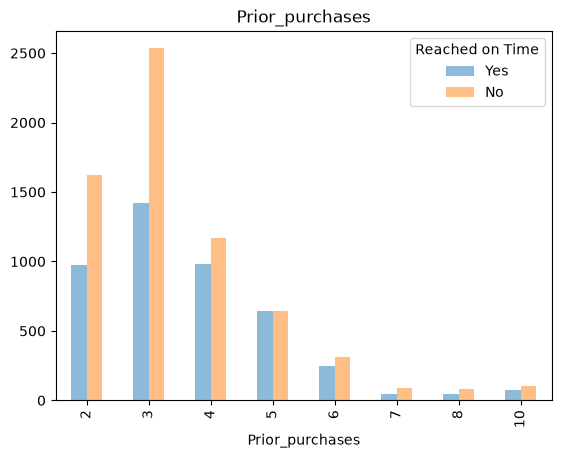

<Figure size 1000x500 with 0 Axes>

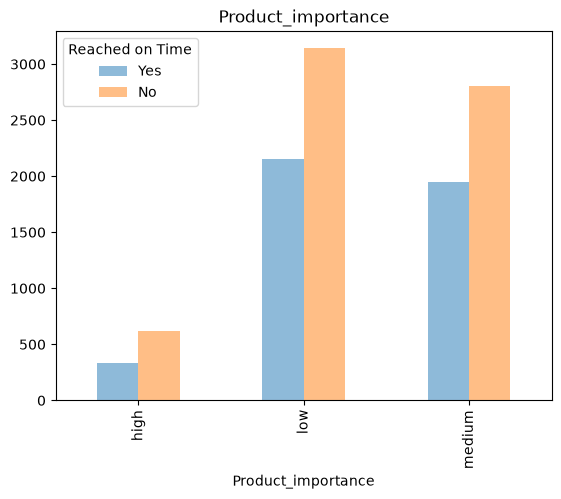

<Figure size 1000x500 with 0 Axes>

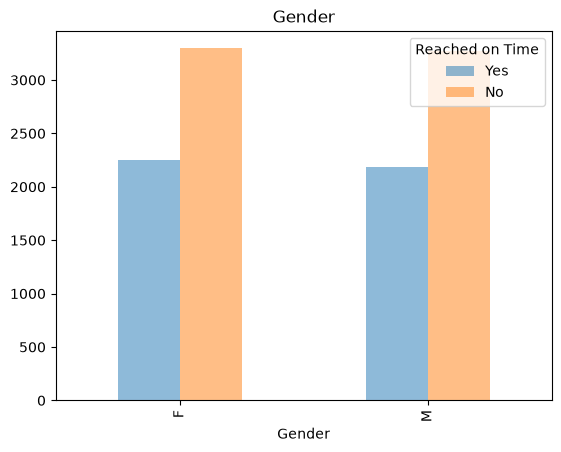

<Figure size 1000x500 with 0 Axes>

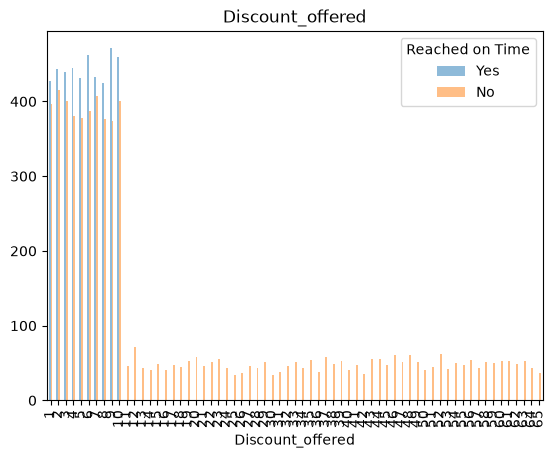

KeyboardInterrupt: 

In [ ]:
import matplotlib.pyplot as plt

df = pd.read_csv('../ressourcen/Train.csv',
                 sep=',',
                 encoding='utf-8',
                 decimal='.'
                 )
df_data = df.drop(columns=['ID'])

mask_onTime = df['Reached.on.Time_Y.N']
for i in df_data.columns[:-1]:
    plt.figure(figsize=(10, 5))
    (
        df_data['Reached.on.Time_Y.N']
        .groupby(df_data[i])
        .value_counts()
        .unstack(fill_value=0)
        .plot(kind='bar', alpha=0.5)
        .legend(title='Reached on Time', labels=['Yes', 'No'])
        .ylabel('Count')
    )
    plt.title(i)
    plt.show()





<Figure size 1000x500 with 0 Axes>

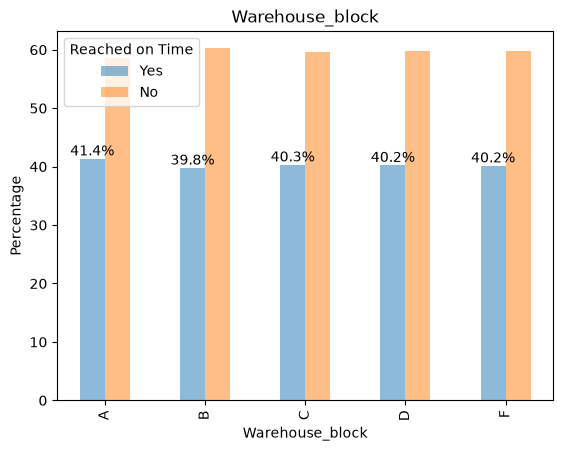

<Figure size 1000x500 with 0 Axes>

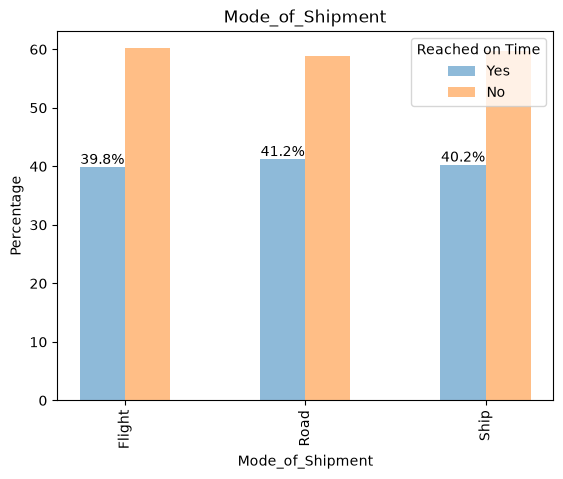

<Figure size 1000x500 with 0 Axes>

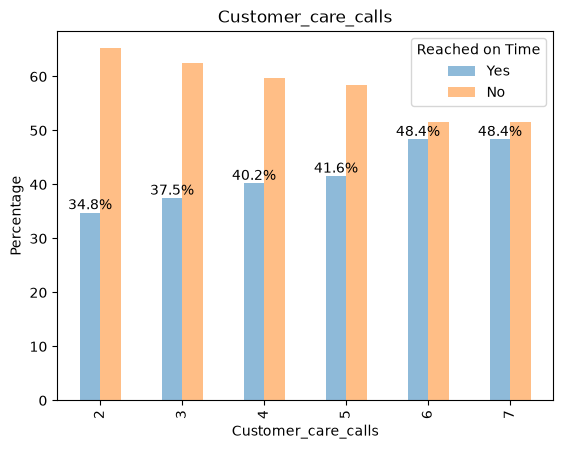

<Figure size 1000x500 with 0 Axes>

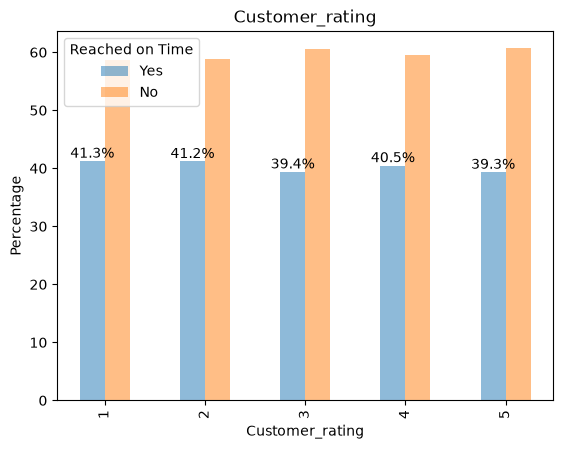

<Figure size 1000x500 with 0 Axes>

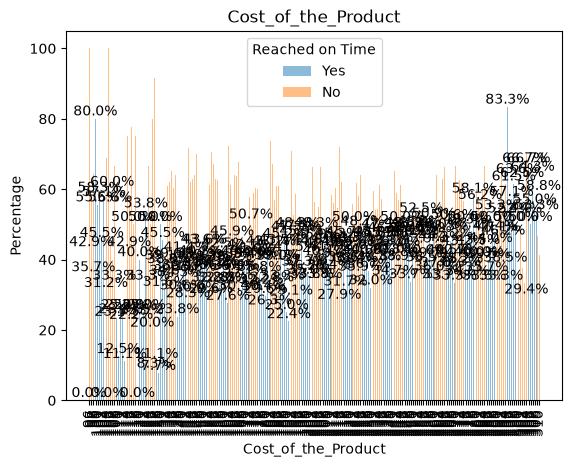

<Figure size 1000x500 with 0 Axes>

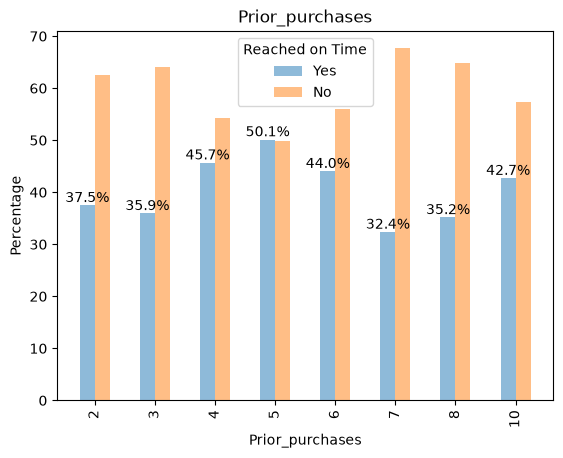

<Figure size 1000x500 with 0 Axes>

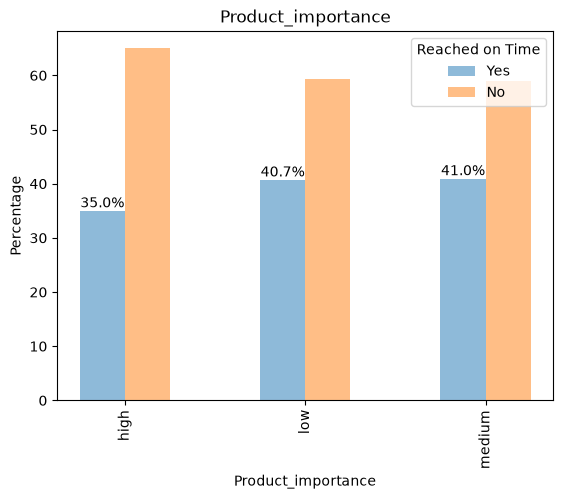

<Figure size 1000x500 with 0 Axes>

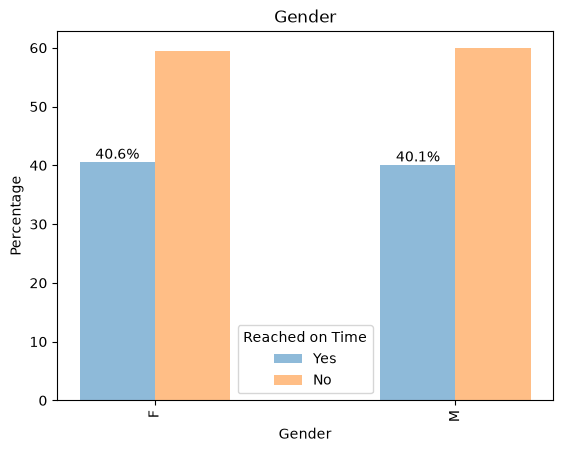

<Figure size 1000x500 with 0 Axes>

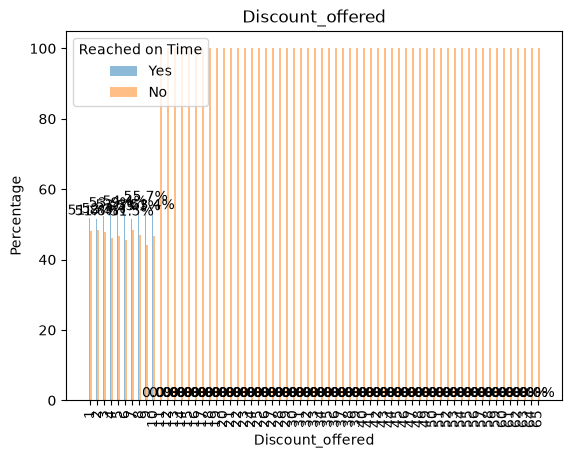

<Figure size 1000x500 with 0 Axes>

/home/rodri/data-science/ds-env/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


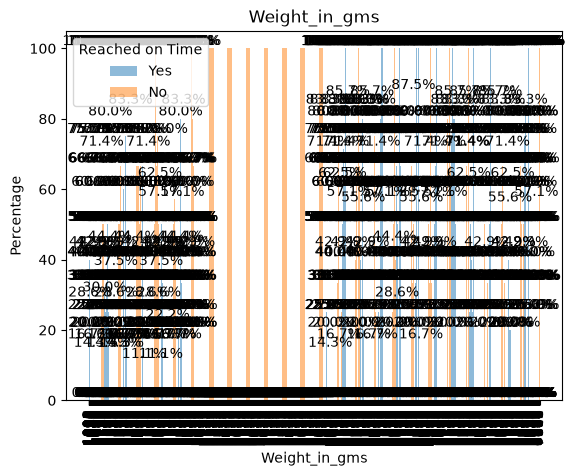

ValueError: index must be a MultiIndex to unstack, <class 'pandas.Index'> was passed

<Figure size 1000x500 with 0 Axes>

In [3]:
df = pd.read_csv('../ressourcen/Train.csv',
                 sep=',',
                 encoding='utf-8',
                 decimal='.'
                 )
df_data = df.drop(columns=['ID'])

for i in df_data.columns[:-1]:
  
    plt.figure(figsize=(10, 5))
    (
        df_data.groupby(i)['Reached.on.Time_Y.N']
        .value_counts(normalize=True)
        .unstack(fill_value=0)
        .mul(100)
        .plot(kind='bar', alpha=0.5)
    )
    plt.legend(title='Reached on Time', labels=['Yes', 'No'])
    plt.ylabel('Percentage')
    plt.autoscale(enable=True, axis='x')
    plt.bar_label(plt.gca().containers[0], fmt='%.1f%%', label_type='edge')
    plt.title(i)
    plt.show()

<Axes: >

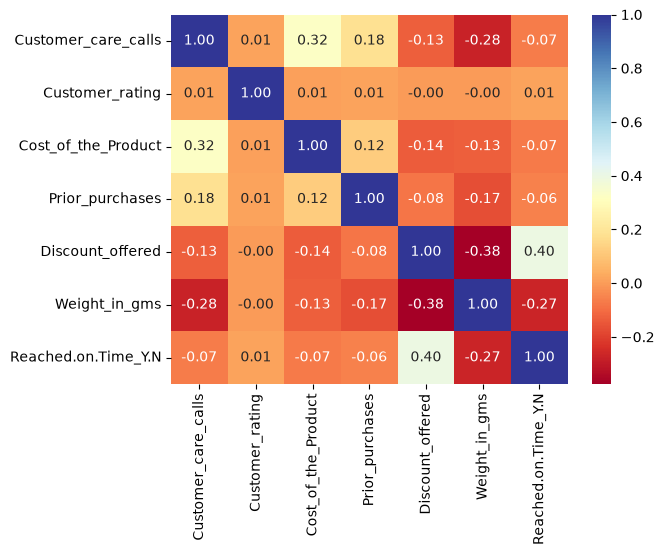

In [9]:
import seaborn as sns
# Option 1: only numeric columns
corr = df_data.select_dtypes(include=["number"]).corr()
sns.heatmap(corr, annot=True, cmap='RdYlBu', fmt=".2f")